# Flow and motion in balanced SSFP

Balanced SSFP is used for bright-blood cardiac cine and for non-contrast angiography, and both
work without any explicit flow compensation. Bieri and Scheffler's review says it "in general
shows quite some robustness against flow or motion", and their earlier paper opens by noting that
it "is often believed to be insensitive and robust against flow or motion" — and then shows where
that belief needs qualifying.

This notebook is about both halves of that. The question is not whether balanced SSFP is "flow
compensated" — it is not, and Part 7 shows what that would take. The question is:

> **Why does conventional balanced SSFP often tolerate ordinary flow well enough to keep useful
> bright-blood signal, and where does that tolerance break down?**

The argument runs through three levels, and keeping them apart is most of the work:

```text
one spin            tells us the PHASE a gradient moment produces
a voxel of spins    tells us whether that phase costs MAGNITUDE
a train of lines    tells us whether the image is consistent from one k-space line to the next
```

Three kinds of statement are also kept apart throughout:

```text
literature establishes    what the papers derive or report
measurement shows         what this implementation's waveform or simulation gives
interpretation            what we read into the two, scoped to what was measured
```

## 1. Why balanced SSFP often looks flow-tolerant

### Bright-blood contrast is not the same thing as gradient-moment compensation

These are separate mechanisms and it is easy to run them together:

```text
flow-independent / flow-tolerant image contrast
        is not
full gradient-moment compensation
```

Time-of-flight angiography depends on *inflow*: vessel signal comes from fresh, unsaturated spins
entering a slab in which stationary tissue has been driven down. Balanced SSFP does not work that
way. Miyazaki and Lee, reviewing non-enhanced MR angiography, put it directly: the technique
"lends itself well to angiographic applications because image contrast is determined by T2/T1
ratios, which produce **bright-blood imaging without reliance on inflow**."

Scheffler and Lehnhardt make the same point from the contrast side — the steady-state signal is
high wherever $T_2/T_1$ is favourable, which is why liquids and fat are both bright "(both have
completely different T1 and T2 values, but a similar ratio of T2 and T1)" — and they note the
consequence for 3D: "**No inflow enhancement can be created in 3D applications** … resulting in a
similar steady-state contrast of blood and other tissues." A 3D balanced-SSFP angiogram is bright
because blood's $T_2/T_1$ is favourable, not because the blood is fresh.

```text
TOF                 vessel signal depends strongly on fresh unsaturated inflow

balanced SSFP       blood is intrinsically bright from its T2/T1 and the coherent steady state
                    -> useful vessel contrast can persist when inflow is slow or in-plane
```

### What the balancing contributes, and what coherence contributes

Two further mechanisms, both from the balanced condition:

**The net zeroth gradient moment returns to zero over each TR.** A stationary spin's
position-dependent phase is wound and rewound within every repetition, so it carries no net
gradient-induced position phase from that balanced interval into the next repetition. Other
phase terms — off-resonance above all — are untouched by that, and are the reason the banding
behaviour exists at all.

**Transverse coherence is preserved rather than spoiled.** Scheffler and Lehnhardt: "Based on its
totally coherent steady-state magnetization, b-SSFP thus offers the highest possible
signal-to-noise ratio per unit time of all known sequences", and at the symmetric echo time the
dephasing "will be nearly completely refocused at TE = TR/2 **leading to the formation of a spin
echo rather than a gradient echo**". The observed signal is therefore not one freshly excited FID;
it is the sum of several coherent pathways that survive from earlier repetitions, which is also
why it does not need fresh inflow to be bright. *(This notebook does not decompose those pathways
— the observable here is the voxel signal.)*

Put together, the heuristic is: when the velocity variation *within a voxel* is small enough that
the motion-induced phases stay clustered, most of the voxel magnitude is preserved — a common
phase rotation is something a magnitude image does not see. Parts 2 and 3 make that statement
precise and show what it depends on, and Part 4 shows a mechanism by which the image can still be
corrupted when each voxel is fine.

**A caution about wording.** "Relatively insensitive" is supportable. "Flow insensitive",
"motion compensated" or "all first moments are zero" are not, and Part 2 measures why.

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import contextlib
import os as _os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 60
warnings.filterwarnings('ignore', message='To copy construct from a tensor')

SEQ_DIR = Path('seq')
#: Every file this notebook writes is a probe -- one k-space line read many times, to isolate a
#: moment, a velocity distribution or a view order.  None of them is an acquisition, and none
#: implements the between-excitations condition Part 7 describes, so they are named for what they
#: measure and kept out of `seq/`, which holds the two acquisitions `01` wrote.
DIAG_DIR = SEQ_DIR / 'diagnostics'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

opts = pp.Opts(
    max_grad=24, grad_unit='mT/m', max_slew=120, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)
FOV_MM, MATRIX, THICKNESS_MM = 250.0, (64, 64), 6.0
FLIP_DEG, BANDWIDTH_HZ_PX = 40.0, 700.0
NX, NY = MATRIX
CENTRE_LINE = NY // 2

PROTOCOL = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX)

conventional = sc.modules.bSSFP2DTR(**PROTOCOL)
print(f'conventional bSSFP   TE {conventional.te_s * 1e3:.3f} ms   '
      f'TR {conventional.tr_s * 1e3:.3f} ms   flip {FLIP_DEG:.0f} deg')
print(f'FOV {FOV_MM:.0f} mm, {NX} x {NY}, {THICKNESS_MM:.0f} mm slice')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


conventional bSSFP   TE 3.225 ms   TR 6.450 ms   flip 40 deg
FOV 250 mm, 64 x 64, 6 mm slice


## 2. One moving spin, and what it does and does not tell us

A spin at $x(t) = x_0 + vt$ accumulates, between the RF effective centre and the echo,

$$\phi = 2\pi\left(x_0 M_0 + v M_1\right)$$

on each axis, with the moments taken about the RF centre. So the moments are what to measure
first.

Two intervals matter and they mean different things:

```text
at the echo          M0 is the intended k-space position -- so M0y carries ky and is NOT zero
                     M1 is the velocity sensitivity of that acquired line's phase

over RF-to-RF        M0 = 0 is the balanced condition
                     M1 is what Part 4 is about
```

In [2]:
def rf_centres(seq):
    """Absolute time of every RF effective centre, seconds."""
    out, t = [], 0.0
    for i in range(1, len(seq.block_events) + 1):
        block = seq.get_block(i)
        if getattr(block, 'rf', None) is not None:
            out.append(t + float(block.rf.delay) + float(pp.calc_rf_center(block.rf)[0]))
        t += float(seq.block_durations[i])
    return np.array(out)


def moment(seq, start, end, origin, order):
    """``(Mx, My, Mz)`` of the given order over ``[start, end]``, about `origin`."""
    waveforms = seq.waveforms_and_times()[0]
    out = []
    for axis in range(3):
        t, g = waveforms[axis][0], waveforms[axis][1]
        if len(t) == 0:
            out.append(0.0)
            continue
        grid = np.unique(np.concatenate([t[(t > start) & (t < end)], [start, end]]))
        v = np.interp(grid, t, g, left=0.0, right=0.0)
        out.append(float(np.trapezoid(v * (grid - origin) ** order, grid)))
    return np.array(out)


def measure(kernel, line):
    """Moments of one repetition, at the echo and over the RF-to-RF interval."""
    scan = sc.LogicBlock()
    for index in range(3):
        scan.add(index * kernel.tr_s,
                 kernel(line=(line + index) % NY, phase_deg=180.0 * (index % 2)))
    seq = sc.compile(scan, opts)
    c = rf_centres(seq)
    return {
        'm0_te': moment(seq, c[0], c[0] + kernel.te_s, c[0], 0),
        'm1_te': moment(seq, c[0], c[0] + kernel.te_s, c[0], 1),
        'm0_rr': moment(seq, c[0], c[1], c[0], 0),
        'm1_rr': moment(seq, c[0], c[1], c[0], 1),
    }


print(f'{"":34}{"x":>13}{"y":>13}{"z":>13}')
for line in (0, CENTRE_LINE, NY - 1):
    m = measure(conventional, line)
    print(f'ky line {line:2d}')
    for key, label, unit in (('m0_te', '  M0 at the echo', '1/m'),
                             ('m1_te', '  M1 at the echo', 's/m'),
                             ('m0_rr', '  M0 over RF-to-RF', '1/m'),
                             ('m1_rr', '  M1 over RF-to-RF', 's/m')):
        print(f'{label:34}' + ''.join(f'{v:13.4e}' for v in m[key]) + f'   {unit}')

                                              x            y            z
ky line  0
  M0 at the echo                    -4.5475e-13  -1.2800e+02   3.8369e-13   1/m
  M1 at the echo                     7.5162e-02  -2.9312e-01  -3.7539e-01   s/m
  M0 over RF-to-RF                  -7.6028e-13   0.0000e+00   2.2737e-13   1/m
  M1 over RF-to-RF                   3.2354e-03   2.3680e-01  -2.2204e-16   s/m
ky line 32
  M0 at the echo                    -4.5475e-13   0.0000e+00   3.8369e-13   1/m
  M1 at the echo                     7.5162e-02   0.0000e+00  -3.7539e-01   s/m
  M0 over RF-to-RF                  -7.6028e-13   0.0000e+00   2.2737e-13   1/m
  M1 over RF-to-RF                   3.2354e-03   0.0000e+00  -2.2204e-16   s/m
ky line 63
  M0 at the echo                    -4.5475e-13   1.2400e+02   3.8369e-13   1/m
  M1 at the echo                     7.5162e-02   2.8396e-01  -3.7539e-01   s/m
  M0 over RF-to-RF                  -7.6028e-13   0.0000e+00   2.2737e-13   1/m
  M1 over RF-

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 138% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 12.560 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 136% at 16.640 ms) (+1 more sites)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode 

```text
measurement shows    over RF-to-RF: M0 = 0 on all three axes; M1z is zero to 2e-16; M1x is
                     3.2e-3 s/m and the SAME for every line; M1y varies with the line.
                     At the echo: M1 is non-zero on all three axes.
```

That interval structure is what Bieri and Scheffler assume for a symmetric 2D scheme — "the time
integral over the readout and slice selection gradient (for the 2D case) is zero- and first-order
flow-compensated within each TR interval", while "PE leads to a nonconstant spin phase evolution
due to changing first-order moments". It comes from arranging each axis symmetrically about the
echo, which `01` builds and measures; `M0 = 0` alone would not give it.

*A discrepancy worth naming.* Their 2013 review instead describes the intrinsic compensation as
being "along the phase and slice directions (for the 2D version)". The measurement here matches
the 2005 statement — readout and slice — and not the 2013 one. Nothing in this notebook depends
on which way round it is stated, but it is not a detail to paper over.

**And at the echo, no axis has zero first moment.** A moving spin does arrive with extra phase.
That is the whole of what a single spin can tell us — checked below against the prediction, with
the simulator's sign convention established first from a known non-zero zeroth moment rather than
assumed.

In [3]:
@contextlib.contextmanager
def quiet():
    """Silence the solver's log, written from MRzero's Rust extension to file descriptor 1."""
    saved, null = _os.dup(1), _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


NAV = pp.make_label(type='SET', label='NAV', value=1)


def write_train(kernel, name, order):
    """A probe train over `order`, every repetition acquired.  NAV, because none of them images."""
    out, at = sc.LogicBlock(name), 0.0
    for index, line in enumerate(order):
        out.add(at, kernel(line=int(line), phase_deg=180.0 * (index % 2)))
        out.add(at, NAV)
        at += kernel.tr_s
    path = DIAG_DIR / f'{name}.seq'
    sc.compile(out, opts, name=name).write(str(path))
    return path


def ensemble(path, kernel, velocities, axis, *, offset_m=0.0, sample=0, T2=0.2):
    """
    One voxel holding ``len(velocities)`` spins, each moving at its own constant velocity.

    Every spin sits at the same position and carries ``1/n`` of the proton density, so what comes
    back is the **complex vector sum** over the ensemble -- which is what a voxel signal is.  A
    single velocity gives the one-spin case.
    """
    n = len(velocities)
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]] * n, PD=[1.0 / n] * n, T1=[1.0] * n, T2=[T2] * n,
        T2dash=[1e3] * n, D=[0.0] * n,
        voxel_size=FOV_MM / NX / 1e3, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0
    base = built.voxel_pos.clone()
    index = 'xyz'.index(axis)
    base[:, index] += offset_m
    speed = torch.tensor(np.asarray(velocities, dtype=float), dtype=base.dtype)

    def motion(t):
        step = torch.zeros((t.numel(), n, 3), dtype=base.dtype)
        step[:, :, index] = speed[None, :] * t[:, None]
        return base[None, :, :] + step

    built.voxel_motion = motion
    imported = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
        signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    rows = signal.reshape(-1, int(kernel.ro.adc.num_samples))
    return rows[:, kernel.ro.echo_sample(0) + sample]


def one_spin(path, kernel, v, axis, **kw):
    """The single-spin case: one velocity, first echo."""
    return ensemble(path, kernel, [v], axis, **kw)[0]


SHORT = write_train(conventional, 'conventional_first_echo_probe', [CENTRE_LINE] * 4)

# ---- the sign convention, established rather than assumed -------------------------------
# A stationary spin displaced along x, read SAMPLES points past the echo, where the readout's
# zeroth moment is known independently: k = SAMPLES / FOV, and the phase is 2*pi*k*x0.
SAMPLES = 8
k_per_m = SAMPLES / (FOV_MM / 1e3)
still = one_spin(SHORT, conventional, 0.0, 'x', sample=SAMPLES)
print(f'static control: stationary spins displaced along x, read {SAMPLES} samples past the '
      f'echo where k = {k_per_m:.1f} 1/m\n')
print(f'{"offset / mm":>12}{"measured / pi":>15}{"2 pi k x0 / pi":>16}{"ratio":>9}')
ratios = []
for offset_mm in (-4.0, -2.0, 2.0, 4.0):
    moved = one_spin(SHORT, conventional, 0.0, 'x', offset_m=offset_mm / 1e3, sample=SAMPLES)
    measured_rad = float(np.angle(moved * np.conj(still)))
    predicted_rad = 2 * np.pi * k_per_m * offset_mm / 1e3
    ratios.append(measured_rad / predicted_rad)
    print(f'{offset_mm:12.1f}{measured_rad / np.pi:15.4f}{predicted_rad / np.pi:16.4f}'
          f'{ratios[-1]:9.3f}')
SIGN = float(np.sign(np.mean(ratios)))
print(f'\nmean ratio {np.mean(ratios):+.3f}: this pipeline reports gradient phase with the '
      f'opposite sign to\nthe 2 pi * moment convention, so a factor of {SIGN:+.0f} is applied '
      f'below.')

static control: stationary spins displaced along x, read 8 samples past the echo where k = 32.0 1/m

 offset / mm  measured / pi  2 pi k x0 / pi    ratio
        -4.0         0.2560         -0.2560   -1.000
        -2.0         0.1280         -0.1280   -1.000
         2.0        -0.1280          0.1280   -1.000
         4.0        -0.2560          0.2560   -1.000

mean ratio -1.000: this pipeline reports gradient phase with the opposite sign to
the 2 pi * moment convention, so a factor of -1 is applied below.


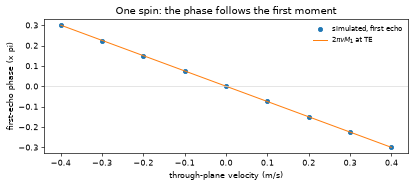

measured slope -2.3526 rad/(m/s),  2 pi M1z = -2.3586  (ratio 0.9974)


In [4]:
VELOCITIES = np.linspace(-0.4, 0.4, 9)
still_z = one_spin(SHORT, conventional, 0.0, 'z')
first_echo = SIGN * np.unwrap([
    float(np.angle(one_spin(SHORT, conventional, v, 'z') * np.conj(still_z)))
    for v in VELOCITIES
])
M1Z = measure(conventional, CENTRE_LINE)['m1_te'][2]

fig, ax = plt.subplots(figsize=(7.0, 3.2))
ax.plot(VELOCITIES, first_echo / np.pi, 'o', ms=5, label='simulated, first echo')
ax.plot(VELOCITIES, 2 * np.pi * VELOCITIES * M1Z / np.pi, '-', lw=1.2,
        label=r'$2\pi v M_1$ at TE')
ax.axhline(0.0, color='0.85', lw=0.8)
ax.set_xlabel('through-plane velocity (m/s)')
ax.set_ylabel('first-echo phase (x pi)')
ax.set_title('One spin: the phase follows the first moment')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

slope = np.polyfit(VELOCITIES, first_echo, 1)[0]
print(f'measured slope {slope:+.4f} rad/(m/s),  2 pi M1z = {2 * np.pi * M1Z:+.4f}  '
      f'(ratio {slope / (2 * np.pi * M1Z):.4f})')

The single-spin prediction holds. **And it is not an image-level result.**

```text
A single spin tells us the phase a gradient moment produces.

It does not by itself tell us
    whether a voxel loses magnitude,
    whether a vessel stays bright,
    or how strong the reconstructed artefact is.
```

For one spin, **phase shift is not signal loss**. A magnitude image is formed from the complex
sum over the spins in a voxel: if they all receive about the *same* extra phase, that sum rotates
and keeps nearly all of its length. It shortens when the phases **disperse**. That is the step
Part 3 measures, and it is the bridge between a moment and an artefact.

## 3. From a spin to a voxel

One voxel, many spins, each moving at its own constant velocity, all at the same position and
each carrying $1/n$ of the proton density — so the simulated signal is exactly the complex vector
sum over the ensemble. Through-plane flow, because that axis carries the largest echo-time first
moment here.

The velocity distributions are **illustrative** and deliberately simple. None of them is a model
of a particular vessel.

In [5]:
N_SPINS = 41
m1z = measure(conventional, CENTRE_LINE)['m1_te'][2]


def phase_range_rad(velocities):
    """
    ``max - min`` of the motion-induced phase across this ensemble.

    A label for these ordered distributions, not a quantity that determines the magnitude: two
    distributions with the same range can have very different complex sums.  The sum is what the
    simulation returns.
    """
    return 2 * np.pi * abs(m1z) * (max(velocities) - min(velocities))


CASES = {
    'static': np.zeros(N_SPINS),
    'uniform 0.3 m/s': np.full(N_SPINS, 0.3),
    'narrow, 0.3 +/- 0.03': np.linspace(0.27, 0.33, N_SPINS),
    'parabolic 0 .. 0.6': 0.6 * (1 - np.linspace(-1, 1, N_SPINS) ** 2),
    'parabolic 0 .. 1.5': 1.5 * (1 - np.linspace(-1, 1, N_SPINS) ** 2),
    'broad 0 .. 2.7': np.linspace(0.0, 2.7, N_SPINS),
    'disturbed, 0.3 +/- 1.35': 0.3 + 1.35 * np.linspace(-1, 1, N_SPINS),
}

reference = ensemble(SHORT, conventional, CASES['static'], 'z')[0]
rows = {}
for name, velocities in CASES.items():
    e = ensemble(SHORT, conventional, velocities, 'z')[0]
    rows[name] = (abs(e) / abs(reference),
                  SIGN * float(np.angle(e * np.conj(reference))),
                  float(np.mean(velocities)), phase_range_rad(velocities))

print(f'{"velocity distribution":26}{"|S| / static":>14}{"phase / pi":>12}'
      f'{"mean v":>9}{"phase range / pi":>18}')
for name, (mag, phase, mean_v, rng) in rows.items():
    print(f'{name:26}{mag:14.3f}{phase / np.pi:12.3f}{mean_v:9.2f}{rng / np.pi:18.3f}')

velocity distribution       |S| / static  phase / pi   mean v  phase range / pi
static                             1.000      -0.000     0.00             0.000
uniform 0.3 m/s                    1.000      -0.225     0.30             0.000
narrow, 0.3 +/- 0.03               0.999      -0.225     0.30             0.045
parabolic 0 .. 0.6                 0.906      -0.295     0.39             0.450
parabolic 0 .. 1.5                 0.519      -0.796     0.97             1.126
broad 0 .. 2.7                     0.035      -0.011     1.35             2.027
disturbed, 0.3 +/- 1.35            0.035       0.775     0.30             2.027


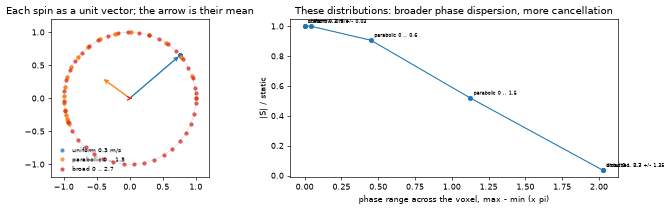

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

show = ('uniform 0.3 m/s', 'parabolic 0 .. 1.5', 'broad 0 .. 2.7')
for name, colour in zip(show, ('C0', 'C1', 'C3')):
    phases = SIGN * 2 * np.pi * CASES[name] * m1z
    axes[0].plot(np.cos(phases), np.sin(phases), 'o', ms=4, color=colour, alpha=0.7, label=name)
    total = np.mean(np.exp(1j * phases))
    axes[0].annotate('', xy=(total.real, total.imag), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=colour, lw=1.6))
axes[0].add_patch(plt.Circle((0, 0), 1.0, fill=False, color='0.85', lw=0.8))
axes[0].set_aspect('equal')
axes[0].set_xlim(-1.2, 1.2)
axes[0].set_ylim(-1.2, 1.2)
axes[0].set_title('Each spin as a unit vector; the arrow is their mean')
axes[0].legend(frameon=False, fontsize=7, loc='lower left')

ranges = [rows[n][3] / np.pi for n in CASES]
mags = [rows[n][0] for n in CASES]
axes[1].plot(ranges, mags, 'o-', lw=1.3, ms=5)
for name in CASES:
    axes[1].annotate(name, (rows[name][3] / np.pi, rows[name][0]), fontsize=6.5,
                     xytext=(4, 4), textcoords='offset points')
axes[1].set_xlabel('phase range across the voxel, max - min (x pi)')
axes[1].set_ylabel('|S| / static')
axes[1].set_title('These distributions: broader phase dispersion, more cancellation')
fig.tight_layout()
plt.show()

```text
measured          a uniform 0.3 m/s rotates the voxel phase by 0.225 pi and leaves |S| at 1.000.
                  A parabolic 0-0.6 m/s profile -- a larger MEAN velocity -- costs 9%.  A broad
                  0-2.7 m/s distribution costs 96%.  The "disturbed" case has the same mean as
                  the uniform one and loses as much as the broad one.

interpretation    a common phase shift does not reduce voxel magnitude.  Magnitude is reduced
                  when the spin phases become dispersed across the voxel and cancel in the
                  complex sum.  Across these illustrative velocity distributions, broader phase
                  dispersion produces greater cancellation.
```

This is the missing link between a first moment and an artefact, and it is why "there is a
non-zero $M_1$" does not by itself predict a dark vessel.

The useful condition is about the *phases*, not about whether the flow pattern looks smooth:

```text
common or narrowly distributed phase    little intravoxel cancellation
broad phase distribution                cancellation, and magnitude loss
```

A perfectly laminar profile can still hold substantial velocity variation across a voxel — the
parabolic rows above are smooth and still lose 9 % and 48 % — so "smooth" is not the criterion.
What matters is whether the motion-induced phases stay clustered over the voxel, and that depends
on the velocity *variation* within it, the first moment, and the voxel size together.

The measure printed above is the phase **range**, `max − min`, which is a convenient label for
these ordered distributions and not a quantity that determines the magnitude: two distributions
with the same range can sum very differently. The sum is what the simulation computes.

The distributions are illustrative. A real voxel also mixes partial-volume boundaries,
acceleration and off-resonance, none of which is modelled here.

## 4. Across repetitions: k-space consistency

A voxel can keep its magnitude and the image can still be wrong, because an image is built from
many repetitions and the phase history has to be **consistent between them**.

That is Bieri and Scheffler's Eq. [1]: the accumulated spin phase $\varphi(n)$ within the $n$-th
TR must satisfy $\varphi(n) = \varphi(n+1)$ for the magnetisation to stay in a steady state.
Anything that varies the phase from one repetition to the next perturbs it — and what varies, for
a moving spin, is the phase-encode first moment, because that is the one term that changes with
the line being acquired. Their Eq. [2]:

$$\Delta\varphi_{PE}(n \to n+1) = \gamma\, v_{PE} \int_0^{TR}\left[G_{PE}(n+1,t) - G_{PE}(n,t)\right] t\,\mathrm{d}t$$

Their simulations put the onset of signal loss near $\Delta\varphi_{PE} \approx 1°$ and
significant perturbation above $2°$, and for standard 2D parameters they evaluate the increment
at about $2°/(\mathrm{m/s})$ — a critical velocity near 0.5–1 m/s for linear view ordering.

How large that increment is depends on how far apart in k-space two *consecutively acquired*
lines are, which is view ordering — written in the acquisition, not in the repetition.

In [7]:
m1y_of = {line: measure(conventional, line)['m1_rr'][1] for line in (0, CENTRE_LINE)}
slope = (m1y_of[CENTRE_LINE] - m1y_of[0]) / CENTRE_LINE       # s/m per line
intercept = m1y_of[0]
print(f'M1y over RF-to-RF is linear in the line index: {slope:+.4e} s/m per line')


def phi_increment_deg_per_m_s(order):
    """Bieri Eq. [2] for a view order: |phase increment| between consecutive acquired lines."""
    m1 = intercept + slope * np.asarray(order, dtype=float)
    return np.degrees(2 * np.pi * np.abs(np.diff(m1)))


linear = list(range(NY))
centric = sorted(range(NY), key=lambda k: (abs(k - CENTRE_LINE), k))
paired = []
for k in centric:
    if k in paired:
        continue
    paired.append(k)
    partner = k + 1 if (k + 1 < NY and k + 1 not in paired) else k - 1
    if 0 <= partner < NY and partner not in paired:
        paired.append(partner)

ORDERS = {'linear': linear, 'paired centric': paired, 'centric': centric}
print(f'\n{"view order":16}{"median":>10}{"mean":>10}{"max":>10}   deg per (m/s)'
      f'{"v at 1 deg":>22}')
for name, order in ORDERS.items():
    d = phi_increment_deg_per_m_s(order)
    print(f'{name:16}{np.median(d):10.2f}{d.mean():10.2f}{d.max():10.2f}'
          f'{1.0 / np.median(d):16.2f} m/s')
print(f'\nBieri: onset of signal loss near 1 deg, significant perturbation above 2 deg.')
print(f'Their figure for FOV 300 mm, TR 5 ms, 256^2 is about 2 deg/(m/s); the protocol here is '
      f'{np.median(phi_increment_deg_per_m_s(linear)):.1f}.')

M1y over RF-to-RF is linear in the line index: -7.4000e-03 s/m per line

view order          median      mean       max   deg per (m/s)            v at 1 deg
linear                2.66      2.66      2.66            0.38 m/s
paired centric        2.66     43.30    165.17            0.38 m/s
centric              85.25     85.25    167.83            0.01 m/s

Bieri: onset of signal loss near 1 deg, significant perturbation above 2 deg.
Their figure for FOV 300 mm, TR 5 ms, 256^2 is about 2 deg/(m/s); the protocol here is 2.7.


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 138% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 12.560 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 136% at 16.640 ms) (+1 more sites)
  seq = sc.compile(scan, opts)


Bieri's **pairing** concept is the remedy that needs no gradient change: order the table so
consecutive lines are adjacent, and "such a pair … intrinsically cancels the preceding dephasing
by simply reproducing the same phase error into the succeeding PE step". Their volunteer images
with pairing were comparable to fully compensated ones. The median above shows pairing restoring
the linear value inside each pair; the cancellation between pairs is their argument and is not
simulated here.

### The whole train

Now the image-level question: does a train that is balanced repetition by repetition still get
corrupted? The train settles first at a constant line — constant PE, so zero increment — and the
phase-encode table then starts, so `M1y` really does change from one repetition to the next.

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/3737637110.py:25: SeqCraftWarning: 102 blocks over the vector-norm limit (legal on real amplifiers): conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.CartesianLine, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 140% at 1293.740 ms), conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 138% at 1296.110 ms), conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.CartesianLine, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 138% at 1300.190 ms), conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 136% at 1302.560 ms), conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.CartesianLine, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 136% at 1306.640 ms) (+97 more sites)
  sc.compile(out, opts

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/3737637110.py:25: SeqCraftWarning: 102 blocks over the vector-norm limit (legal on real amplifiers): conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.CartesianLine, conventional_centric_order_probe.bSSFP2DTR.PhaseEncode (slew 100% at 1351.790 ms), conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.CartesianLine, conventional_centric_order_probe.bSSFP2DTR.PhaseEncode (slew 100% at 1358.240 ms), conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.CartesianLine, conventional_centric_order_probe.bSSFP2DTR.PhaseEncode (slew 101% at 1364.690 ms), conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.CartesianLine, conventional_centric_order_probe.bSSFP2DTR.PhaseEncode (slew 101% at 1371.140 ms), conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.Cartesi

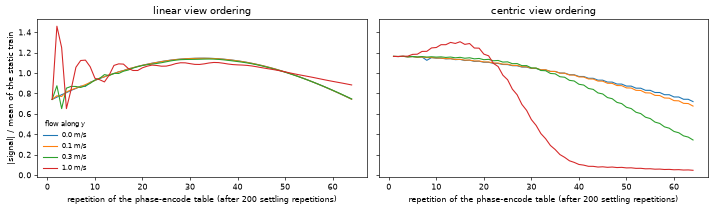

ordering      v (m/s)   mean |S| / static   std / mean  Bieri d phi (deg)
linear           0.00               1.000        0.126               0.00
linear           0.10               1.000        0.125               0.27
linear           0.30               0.998        0.123               0.80
linear           1.00               1.029        0.106               2.66
centric          0.00               1.000        0.134               0.00
centric          0.10               0.993        0.148               8.52
centric          0.30               0.913        0.287              25.57
centric          1.00               0.586        0.888              85.25


In [8]:
SETTLE = 200
TRAINS = {name: write_train(conventional, f'conventional_{name}_order_probe',
                            [CENTRE_LINE] * SETTLE + list(order))
          for name, order in (('linear', linear), ('centric', centric))}

FLOW = [0.0, 0.1, 0.3, 1.0]            # m/s along y, the phase-encode axis
trains = {name: {v: np.abs(ensemble(path, conventional, [v], 'y'))[SETTLE:] for v in FLOW}
          for name, path in TRAINS.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, label in zip(axes, trains):
    for v in FLOW:
        s = trains[label][v]
        ax.plot(np.arange(len(s)) + 1, s / trains[label][0.0].mean(), lw=1.3,
                label=f'{v:.1f} m/s')
    ax.set_title(f'{label} view ordering')
    ax.set_xlabel(f'repetition of the phase-encode table (after {SETTLE} settling repetitions)')
axes[0].set_ylabel('|signal| / mean of the static train')
axes[0].legend(frameon=False, fontsize=8, title='flow along y', title_fontsize=8)
fig.tight_layout()
plt.show()

print(f'{"ordering":12}{"v (m/s)":>9}{"mean |S| / static":>20}{"std / mean":>13}'
      f'{"Bieri d phi (deg)":>19}')
for label, order in (('linear', linear), ('centric', centric)):
    d = np.median(phi_increment_deg_per_m_s(order))
    ref = trains[label][0.0].mean()
    for v in FLOW:
        s = trains[label][v]
        print(f'{label:12}{v:9.2f}{s.mean() / ref:20.3f}{s.std() / s.mean():13.3f}'
              f'{d * v:19.2f}')

```text
literature        Bieri & Scheffler report onset of signal loss near 1 deg of increment and
                  significant perturbation above 2 deg, for their protocol and simulation.

measured          with linear ordering the mean signal stays within a few per cent of the static
                  train at every velocity up to 1 m/s, where the Eq. [2] increment reaches
                  2.7 deg.  With centric ordering the same velocities give increments of 9 to
                  85 deg, and the train loses a tenth of its mean at 0.3 m/s and over 40% at
                  1 m/s, with the repetition-to-repetition scatter rising sharply.

interpretation    larger repetition-to-repetition phase increments produce much stronger
                  steady-state perturbation here, which is qualitatively the mechanism Bieri &
                  Scheffler describe.  The present protocol and simulator do NOT reproduce their
                  numerical threshold: at 2.7 deg the linear train is still close to the static
                  one, slightly above it.  What the increment orders is which configurations
                  degrade more, not where a threshold sits.  And this is ONE failure mechanism,
                  not the whole story of flow in balanced SSFP.
```

This is also the level at which "each repetition is balanced" stops being sufficient: every
repetition in both trains satisfies `M0 = 0` on every axis, and the centric one still degrades
badly.

*On reading the table.* Repeating this cell moves the mean ratios in the third decimal — the
solver's state pruning is not bit-reproducible run to run — so the figures here are good to about
a per cent, and the comparison worth reading is between rows rather than between their last
digits.

## 5. Where the heuristic fails

Collecting the mechanisms, with what established each:

```text
velocity dispersion inside a voxel       Part 3: when the motion-induced phases disperse
                                         across the voxel the complex sum shortens.  A steep
                                         profile across a small vessel, a jet or turbulence
                                         can do that.

large k-space jumps between lines        Part 4 and Bieri Eq. [2]: a view order whose
                                         consecutive lines are far apart in k-space raises the
                                         repetition-to-repetition increment by an order of
                                         magnitude or more.  Centric ordering does that here.
                                         Whether a segmented order does depends on its view-order
                                         policy, not on being segmented.

high velocity ON AN AXIS WHOSE           every phase term above is a product of a velocity and
RELEVANT MOMENT IS NON-ZERO              a moment.  A large velocity along an axis whose
OR CHANGING                              relevant moment is zero, or unchanging between
                                         repetitions, contributes nothing -- velocity on its own
                                         is not a failure mechanism.  Bieri put the critical
                                         velocity at roughly 0.5-1 m/s for standard linear
                                         ordering on their protocol.

acceleration and higher-order motion     only the first moment enters the phase above.  A spin
                                         that is accelerating carries terms this notebook does
                                         not measure at all.

off-resonance                            the steady state is a function of the phase per TR, and
                                         Bieri note that steady-state signal modulations "also
                                         depend on local field inhomogeneities and become
                                         stronger with increasing off-resonance".

outflow                                  below.
```

### Outflow: the same coherence, working against the image

The preserved coherence that makes ordinary flow benign also lets a spin keep contributing after
it has left the slice. Markl and Pelc's study is about exactly this: flow-related signal change in
balanced SSFP "predominantly has to be associated with frequency offset-dependent outflow effects
and a resulting broadening of the slice thickness", with an effective slice thickness that "can be
as large as 15 times the prescribed slice thickness", producing "large frequency offset-dependent
signal enhancement, pulsatile flow artifacts, and spatial misrepresentation of blood signal that
has already left the imaging slice".

```text
spin excited in the slice
    -> flows out of the nominal slice
    -> transverse coherence persists, because nothing spoils it
    -> it keeps contributing signal
    -> effective slice broadening, out-of-slice signal, misregistration
```

That mechanism is about through-slice transport and slice profile rather than about gradient
moments, and **nothing here simulates it** — the ensemble above translates spins without
re-applying a slice profile. It is named because a notebook that stopped at "balanced, therefore
robust" would be leaving out the artefact balanced SSFP is most known for.

## 6. Why this matters for balanced-SSFP angiography

The question this notebook opened with, answered from the parts above:

```text
literature        contrast is set by T2/T1, which gives bright blood "without reliance on
                  inflow" (Miyazaki & Lee), and in 3D there is no inflow enhancement at all
                  (Scheffler & Lehnhardt) -- the blood is bright because of its relaxation
                  times and the coherent steady state.

                  Both arteries and veins are bright, and bSSFP angiography often uses
                  preparation to separate arterial from venous or background signal rather than
                  relying on flow.

measured          a common velocity rotates a voxel's phase and leaves its magnitude intact;
                  magnitude falls with phase SPREAD.  Under linear ordering the
                  repetition-to-repetition increment stays below Bieri's threshold for
                  sub-m/s flow on this protocol.

interpretation    bSSFP angiography works without explicit flow compensation because its
                  contrast does not depend on inflow, and because ordinary smooth flow
                  perturbs phase more than magnitude.  Slow and in-plane flow can remain
                  visible, which is the case TOF struggles with.
```

And the qualification, which matters as much:

```text
this does not mean flow has no effect.  High velocities, broad velocity distributions and
turbulence, acceleration, off-resonance, outflow, and large phase-encode jumps all degrade it --
Part 5 lists which part of this notebook or which paper establishes each.
```

**Not** because all the first moments are zero. Part 2 measured that they are not.

*One place the literature is not uniform.* Miyazaki and Lee describe a balanced-SSFP sequence used
for renal angiography as "fully flow compensated in all three directions". That is a statement
about a particular implementation with explicit compensation, not about balanced SSFP in general,
and it is not what the waveform measured in Part 2 does.

## 7. Explicit compensation

Everything so far is the conventional sequence. Where the tolerance is not enough — high
velocities, or a view order with large k-space jumps — there are two interventions, and they are
not the same one.

### 7a. Generic echo-time first-moment compensation

`sc.FlowCompensation` means, across SeqCraft, *null the first moment at the echo*. That is the
right condition for a spoiled gradient echo, where the acquired line's phase is the whole story.

In [9]:
compensated = sc.modules.bSSFP2DTR(**PROTOCOL,
                                   flow_comp=sc.FlowCompensation(axis=('x', 'y', 'z')))

print(f'{"":36}{"x":>13}{"y":>13}{"z":>13}   (s/m)')
for name, kernel in (('conventional', conventional), ('flow_comp=', compensated)):
    for line in (0, NY - 1):
        m = measure(kernel, line)
        print(f'{name:22} ky {line:2d}  M1 at the echo ' + ''.join(f'{v:13.4e}'
                                                                   for v in m['m1_te']))
        print(f'{"":22}        M1 over RF-to-RF' + ''.join(f'{v:13.4e}' for v in m['m1_rr']))
    print()

comp_m1y = {line: measure(compensated, line)['m1_rr'][1] for line in (0, CENTRE_LINE)}
comp_slope = (comp_m1y[CENTRE_LINE] - comp_m1y[0]) / CENTRE_LINE


def increment(slope_value, order):
    return np.degrees(2 * np.pi * np.abs(np.diff(slope_value * np.asarray(order, float))))


print(f'{"":22}{"TE (ms)":>10}{"TR (ms)":>10}{"1/TR (Hz)":>12}'
      f'{"median d phi, linear":>24}')
for name, kernel, s in (('conventional', conventional, slope),
                        ('flow_comp=', compensated, comp_slope)):
    print(f'{name:22}{kernel.te_s * 1e3:10.3f}{kernel.tr_s * 1e3:10.3f}'
          f'{1 / kernel.tr_s:12.1f}{np.median(increment(s, linear)):24.2f}')
ratio = np.median(increment(comp_slope, linear)) / np.median(increment(slope, linear))
print(f'\nflow_comp= is {ratio:.1f}x LARGER on the quantity Bieri Eq. [2] names.')

                                                x            y            z   (s/m)
conventional           ky  0  M1 at the echo    7.5162e-02  -2.9312e-01  -3.7539e-01
                              M1 over RF-to-RF   3.2354e-03   2.3680e-01  -2.2204e-16
conventional           ky 63  M1 at the echo    7.5162e-02   2.8396e-01  -3.7539e-01
                              M1 over RF-to-RF   3.2354e-03  -2.2940e-01  -2.2204e-16

flow_comp=             ky  0  M1 at the echo    4.7833e-05   8.8818e-16  -9.2593e-05
                              M1 over RF-to-RF  -1.8180e-01   8.5568e-01   3.7530e-01
flow_comp=             ky 63  M1 at the echo    4.7833e-05  -8.8818e-16  -9.2593e-05
                              M1 over RF-to-RF  -1.8180e-01  -8.2894e-01   3.7530e-01

                         TE (ms)   TR (ms)   1/TR (Hz)    median d phi, linear
conventional               3.225     6.450       155.0                    2.66
flow_comp=                 4.925     9.850       101.5                  

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 138% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 12.560 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 136% at 16.640 ms) (+1 more sites)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode 

```text
measured          flow_comp= drives M1 at the echo to near zero on all three axes.  Over the
                  RF-to-RF interval it undoes the symmetric structure Part 2 measured, and the
                  phase-encode increment grows by a factor of about 3.6.  TE and TR grow ~53%,
                  which narrows the off-resonance band spacing from 155 to 102 Hz.

interpretation    this is **explicit echo-time first-moment compensation**.  It meets that
                  condition, and it is useful where the goal is to suppress constant-velocity
                  phase at the acquired echo.  It is a different endpoint from the bSSFP one,
                  and reaching it costs the structure that made the conventional repetition
                  first-order balanced between excitations.
```

It is not called flow-compensated bSSFP, motion-robust bSSFP, or a Bieri-style design anywhere in
this notebook. **Its waveform is not supposed to resemble Bieri's Fig. 2** — that figure solves a
different endpoint and is organised symmetrically about TE for that reason, while this one solves
for the moment at the echo, so asymmetry over the interval is what the requirement produces
rather than a failure to meet it.

### 7b. Bieri-style between-excitation compensation

The literature's bSSFP condition is on the other interval:

```text
over [RF centre n, RF centre n+1]      M0 = 0   and   M1 = 0   on the compensated axes
```

Bieri and Scheffler are explicit that this is what their design nulls and that it is *not* the
echo-time moment: the compensation "nulls the first moment between excitations, but does not null
the first moment between the excitation and echo. However, the flow sensitivity of the b-SSFP
signal at TE is relatively small and adds only a small phase to the corresponding k-space line.
It does not perturb steady state." Part 3 is why that is reasonable — a small common phase on one
line is not a magnitude artefact.

How much of it the conventional repetition already satisfies:

In [10]:
rows = [(line, measure(conventional, line)) for line in (0, CENTRE_LINE, NY - 1)]
print('Bieri-style condition, against the conventional symmetric repetition\n')
print(f'{"axis":6}{"M0 over TR":>14}{"M1 over TR":>16}   verdict')
for axis, name in enumerate('xyz'):
    m0 = max(abs(r[1]['m0_rr'][axis]) for r in rows)
    m1 = [r[1]['m1_rr'][axis] for r in rows]
    if max(abs(v) for v in m1) < 1e-9:
        verdict = 'met'
    elif np.ptp(m1) < 1e-12:
        verdict = f'constant {m1[0]:+.1e}: a constant per-TR phase, which Eq. [1] allows'
    else:
        verdict = f'varies with the line, {min(m1):+.3f} .. {max(m1):+.3f}: NOT met'
    print(f'{name:6}{m0:14.2e}{max(abs(v) for v in m1):16.2e}   {verdict}')

Bieri-style condition, against the conventional symmetric repetition

axis      M0 over TR      M1 over TR   verdict
x           7.60e-13        3.24e-03   constant +3.2e-03: a constant per-TR phase, which Eq. [1] allows
y           0.00e+00        2.37e-01   varies with the line, -0.229 .. +0.237: NOT met
z           2.27e-13        2.22e-16   met


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 138% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 12.560 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 136% at 16.640 ms) (+1 more sites)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_77047/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode 

So the remaining work is the phase-encode axis alone — which is what Bieri's Fig. 2a addresses:
"Extra gradient moments with opposite sign … complement PE to null the first-order PE gradient
moment within TR." A blip and its rewind are a dipole: two lobes of equal area and opposite sign,
whose first moment over the interval cannot vanish while their separation does not. Nulling it
needs more lobes on `y`, arranged symmetrically about TE so the rest of the structure survives,
and it costs TR — Bieri report about +50 % for their 3D scheme.

**It is not implemented here**, and no file in `seq/diagnostics/` represents it. The condition is
stated and the gap is measured, which is what a decision needs; inventing the waveform from a
reading of a figure is not. Two things that decision involves:

- `sc.FlowCompensation` means echo-time nulling across SeqCraft, and that meaning is right for a
  spoiled gradient echo. A between-excitations condition is a different endpoint and would need
  its own way of being asked for rather than a redefinition of this one.
- Bieri's pairing needs no gradient change at all, and §4 measured what it does to the increment.
  Ordering is written in the acquisition, so it is available today — in the loop in
  [`01_build.ipynb`](01_build.ipynb).

## Summary

The progression this notebook is built on:

```text
one spin            tells us the phase a gradient moment produces
a voxel of spins    tells us whether that phase costs magnitude
a train of lines    tells us whether the image is consistent from line to line
```

**Why conventional balanced SSFP often tolerates ordinary flow**

1. Blood is intrinsically bright from its $T_2/T_1$ and the coherent steady state; the contrast
   does not depend on fresh inflow (Miyazaki & Lee; Scheffler & Lehnhardt).
2. Gradients return to zero each TR, so a stationary spin's position phase is rewound.
3. Transverse coherence is preserved rather than spoiled, and the symmetric echo is spin-echo-like
   rather than a simple FID (Scheffler & Lehnhardt; Bieri & Scheffler 2013).
4. When velocity variation within a voxel is small enough that the motion-induced phases stay
   clustered, the complex sum keeps its length — a common rotation costs no magnitude. Measured
   in Part 3.
5. Under linear phase-encode ordering the repetition-to-repetition increment stays small —
   measured in Part 4 against Bieri's threshold.

**Scoped conclusion**

Conventional balanced SSFP has several mechanisms that make ordinary smooth flow relatively
benign in magnitude imaging, which helps explain its use for bright-blood cine and
flow-independent angiography. Those mechanisms are **not** equivalent to full flow compensation,
and they fail under specific motion, ordering, off-resonance and outflow conditions — each named
in Part 5 with what establishes it.

**What this notebook does not establish**

- Anything about a particular vessel. The velocity distributions in Part 3 are illustrative, and
  no partial-volume, acceleration or pulsatility model is included.
- The outflow mechanism, which is cited and not simulated.
- Anything about a real scanner: MRzero applies each pulse as a rotation by its integrated
  envelope, and the motion model translates spins at constant velocity.
- That any of this transfers to another protocol. One TR, one flip angle, one matrix.

## References

1. Bieri O, Scheffler K. *Flow compensation in balanced SSFP sequences.* Magn Reson Med
   2005;54:901–907. — Eqs. [1] and [2], the 1–2° threshold, the 0.5–1 m/s critical velocity, the
   pairing concept, and which interval their compensation nulls.
2. Bieri O, Scheffler K. *Fundamentals of balanced steady state free precession MRI.* J Magn
   Reson Imaging 2013;38:2–11. — "quite some robustness against flow or motion"; the spin-echo
   character of the symmetric echo; the intrinsic-compensation statement discussed in Part 2.
3. Scheffler K, Lehnhardt S. *Principles and applications of balanced SSFP techniques.* Eur
   Radiol 2003;13:2409–2418. — the coherent steady state, $T_2/T_1$ contrast, the spin echo at
   TE = TR/2, and the absence of inflow enhancement in 3D.
4. Markl M, Pelc NJ. *On flow effects in balanced steady-state free precession imaging.* J Magn
   Reson Imaging 2004;20:697–705. — outflow, effective slice broadening, frequency-offset
   dependence.
5. Miyazaki M, Lee VS. *Nonenhanced MR angiography.* Radiology 2008;248:20–43. — bright-blood
   contrast from $T_2/T_1$ "without reliance on inflow", and balanced-SSFP angiographic practice.
6. Bernstein MA, King KF, Zhou XJ. *Handbook of MRI Pulse Sequences.* Elsevier, 2004, §9.2
   (gradient moment nulling) and §14.1 (balanced SSFP).